In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random


Number of normal images in training set: 1342
Number of pneumonia images in training set: 3876
Number of normal images in validation set: 9
Number of pneumonia images in validation set: 9
Number of normal images in test set: 234
Number of pneumonia images in test set: 390


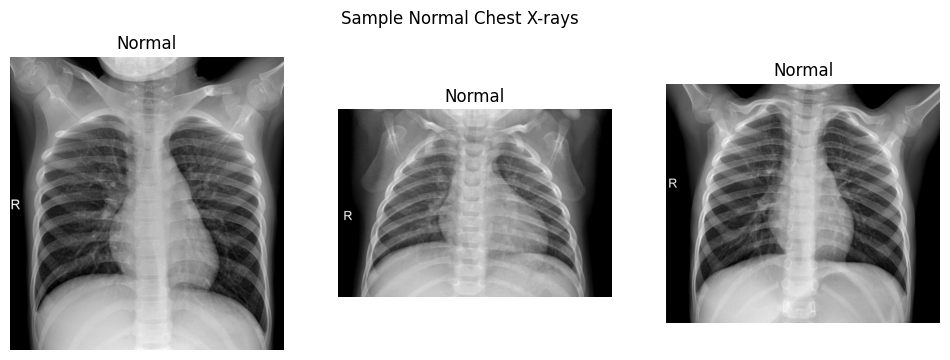

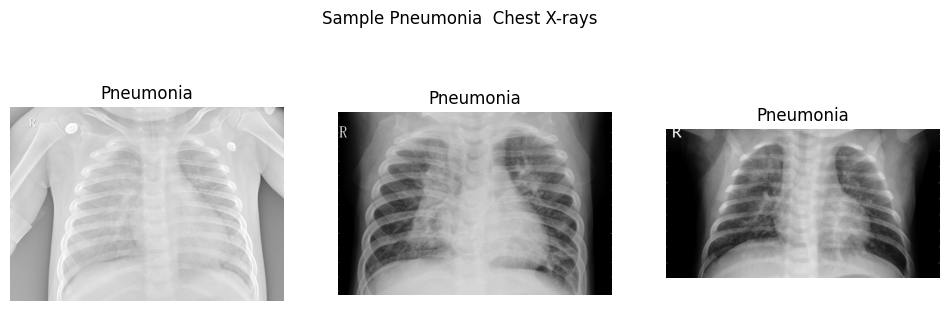

In [4]:
base_dir = '../data/raw'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
val_dir = os.path.join(base_dir, 'val')

train_normal_dir = os.path.join(train_dir, 'NORMAL')
train_pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')

val_normal_dir = os.path.join(val_dir, 'NORMAL')
val_pneumonia_dir = os.path.join(val_dir, 'PNEUMONIA')

test_normal_dir = os.path.join(test_dir, 'NORMAL')
test_pneumonia_dir = os.path.join(test_dir, 'PNEUMONIA')

print(f"Number of normal images in training set: {len(os.listdir(train_normal_dir))}")
print(f"Number of pneumonia images in training set: {len(os.listdir(train_pneumonia_dir))}")
print(f"Number of normal images in validation set: {len(os.listdir(val_normal_dir))}")
print(f"Number of pneumonia images in validation set: {len(os.listdir(val_pneumonia_dir))}")
print(f"Number of normal images in test set: {len(os.listdir(test_normal_dir))}")
print(f"Number of pneumonia images in test set: {len(os.listdir(test_pneumonia_dir))}")

# Display some sample images

normal_images = os.listdir(train_normal_dir)
pneumonia_images = os.listdir(train_pneumonia_dir)

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    img_name = random.choice(normal_images)
    img_path = os.path.join(train_normal_dir, img_name)
    img = mpimg.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.title('Normal')
    plt.axis('off')
plt.suptitle('Sample Normal Chest X-rays')
plt.show()

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    img_name = random.choice(pneumonia_images)
    img_path = os.path.join(train_pneumonia_dir, img_name)
    img = mpimg.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.title('Pneumonia')
    plt.axis('off')
plt.suptitle('Sample Pneumonia  Chest X-rays')
plt.show()

/tmp/ipykernel_26388/478230603.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


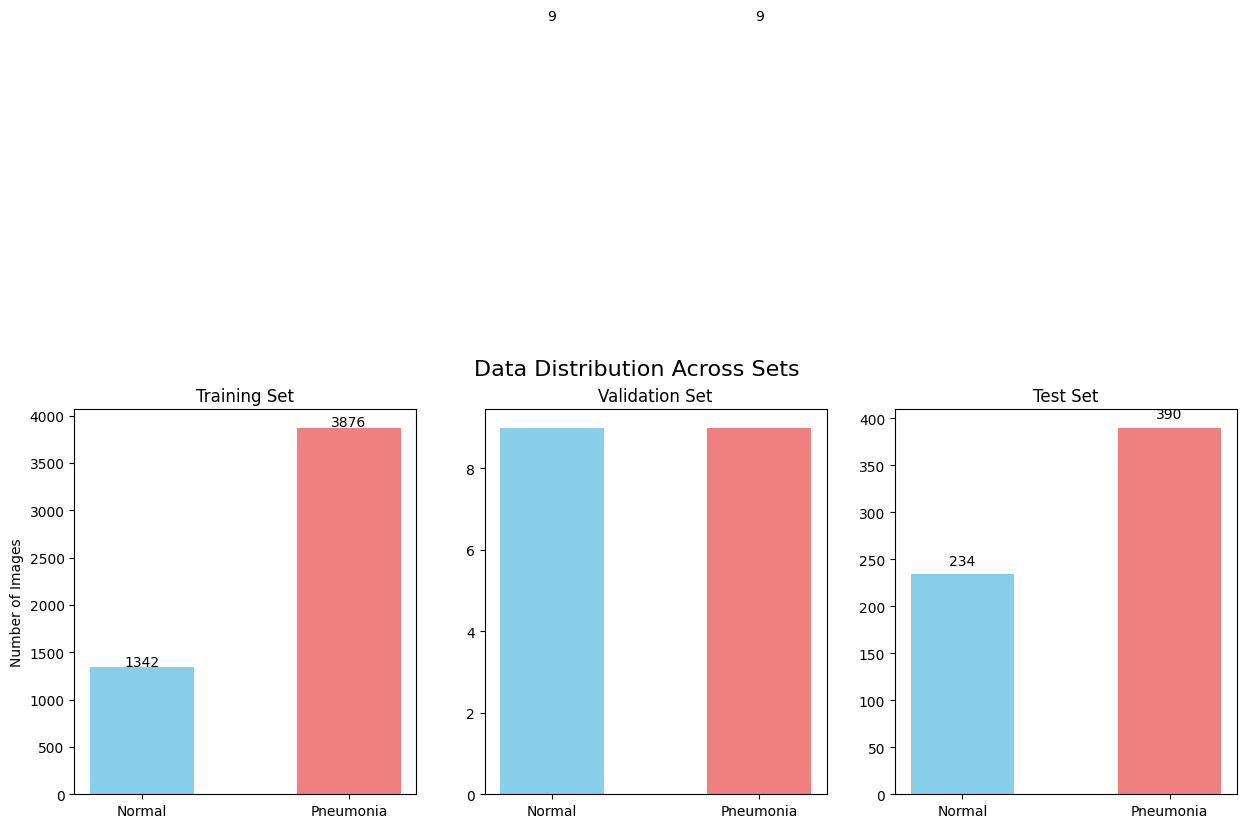

In [5]:
import numpy as np

num_train_normal = len(os.listdir(train_normal_dir))
num_train_pneumonia = len(os.listdir(train_pneumonia_dir))
num_val_normal = len(os.listdir(val_normal_dir))
num_val_pneumonia = len(os.listdir(val_pneumonia_dir))
num_test_normal = len(os.listdir(test_normal_dir))
num_test_pneumonia = len(os.listdir(test_pneumonia_dir))

labels = ['Normal', 'Pneumonia']
train_counts = [num_train_normal, num_train_pneumonia]
val_counts = [num_val_normal, num_val_pneumonia]
test_counts = [num_test_normal, num_test_pneumonia]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Data Distribution Across Sets', fontsize=16)

bar_width = 0.5

ax[0].bar(labels, train_counts, color=['skyblue', 'lightcoral'], width=bar_width)
ax[0].set_title('Training Set')
ax[0].set_ylabel('Number of Images')

ax[1].bar(labels, val_counts, color=['skyblue', 'lightcoral'], width=bar_width)
ax[1].set_title('Validation Set')

ax[2].bar(labels, test_counts, color=['skyblue', 'lightcoral'], width=bar_width)
ax[2].set_title('Test Set')

# Add text labels on top of the bars
for i in range(3):
    counts = [train_counts, val_counts, test_counts][i]
    for index, value in enumerate(counts):
        ax[i].text(index, value + 10, str(value), ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



In [6]:
import numpy as np

def calculate_class_weights(num_normal, num_pneumonia):
    total_samples = num_normal + num_pneumonia
    num_classes = 2

    weight_for_0 = total_samples/(num_classes * num_normal)
    weight_for_1 = total_samples/(num_classes * num_pneumonia)

    class_weight = {
        0 : weight_for_0,
        1 : weight_for_1
    }

    print(f"Weight for Class 0 (Normal): {weight_for_0:.2f}")
    print(f"Weight for Class 1 (Pneumonia): {weight_for_1:.2f}")

    return class_weight


train_weights = calculate_class_weights(1342, 3876)

Weight for Class 0 (Normal): 1.94
Weight for Class 1 (Pneumonia): 0.67


In [8]:
import os
import shutil
import random

def create_validation_set(base_dir='data/raw', val_split=0.1):
    """
    Moves a percentage of images from the training set to the validation set.

    Args:
        base_dir (str): The base directory where 'train' and 'val' folders are located.
        val_split (float): The percentage of training data to move to the validation set.
    """
    print("--- Starting Dataset Rebalancing ---")

    train_dir = os.path.join(base_dir, 'train')
    val_dir = os.path.join(base_dir, 'val')

    # Ensure the base validation directories exist
    os.makedirs(os.path.join(val_dir, 'NORMAL'), exist_ok=True)
    os.makedirs(os.path.join(val_dir, 'PNEUMONIA'), exist_ok=True)

    for category in ['NORMAL', 'PNEUMONIA']:
        print(f"\nProcessing category: {category}")

        source_dir = os.path.join(train_dir, category)
        dest_dir = os.path.join(val_dir, category)

        # Get all image files, ignoring subdirectories
        images = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]
        
        
        existing_val_images = [f for f in os.listdir(dest_dir) if os.path.isfile(os.path.join(dest_dir, f))]
        if existing_val_images:
            print(f"Moving {len(existing_val_images)} existing validation images back to the training set for a clean split.")
            for img in existing_val_images:
                shutil.move(os.path.join(dest_dir, img), os.path.join(source_dir, img))
            # Refresh the list of images in the source directory
            images = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]

        num_images = len(images)
        num_to_move = int(num_images * val_split)

        print(f"Total images in train/{category}: {num_images}")
        print(f"Moving {num_to_move} images to val/{category}...")

        # Randomly select images to move
        files_to_move = random.sample(images, num_to_move)

        # Move the files
        for file_name in files_to_move:
            source_path = os.path.join(source_dir, file_name)
            dest_path = os.path.join(dest_dir, file_name)
            shutil.move(source_path, dest_path)

        print(f"Successfully moved {len(os.listdir(dest_dir))} images to val/{category}.")
        print(f"Remaining images in train/{category}: {len(os.listdir(source_dir))}")

    print("\n--- Dataset Rebalancing Complete ---")
    print("Please re-run the data exploration notebook to see the new distribution.")


create_validation_set(base_dir='../data/raw', val_split=0.1)

--- Starting Dataset Rebalancing ---

Processing category: NORMAL
Moving 9 existing validation images back to the training set for a clean split.
Total images in train/NORMAL: 1350
Moving 135 images to val/NORMAL...
Successfully moved 135 images to val/NORMAL.
Remaining images in train/NORMAL: 1215

Processing category: PNEUMONIA
Moving 9 existing validation images back to the training set for a clean split.
Total images in train/PNEUMONIA: 3884
Moving 388 images to val/PNEUMONIA...
Successfully moved 388 images to val/PNEUMONIA.
Remaining images in train/PNEUMONIA: 3496

--- Dataset Rebalancing Complete ---
Please re-run the data exploration notebook to see the new distribution.


Number of normal images in training set: 1080
Number of pneumonia images in training set: 3108
Number of normal images in validation set: 270
Number of pneumonia images in validation set: 776
Number of normal images in test set: 234
Number of pneumonia images in test set: 390


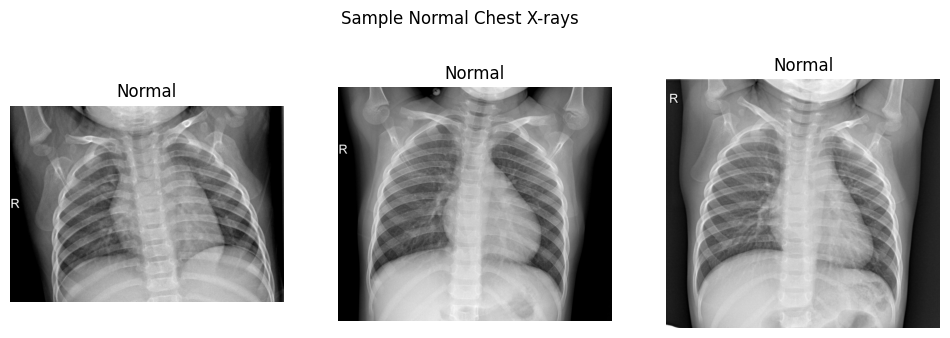

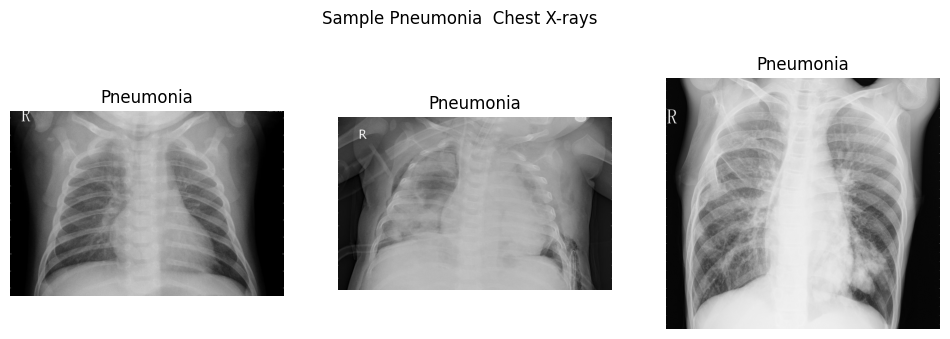

In [2]:
base_dir = '../data/raw'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
val_dir = os.path.join(base_dir, 'val')

train_normal_dir = os.path.join(train_dir, 'NORMAL')
train_pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')

val_normal_dir = os.path.join(val_dir, 'NORMAL')
val_pneumonia_dir = os.path.join(val_dir, 'PNEUMONIA')

test_normal_dir = os.path.join(test_dir, 'NORMAL')
test_pneumonia_dir = os.path.join(test_dir, 'PNEUMONIA')

print(f"Number of normal images in training set: {len(os.listdir(train_normal_dir))}")
print(f"Number of pneumonia images in training set: {len(os.listdir(train_pneumonia_dir))}")
print(f"Number of normal images in validation set: {len(os.listdir(val_normal_dir))}")
print(f"Number of pneumonia images in validation set: {len(os.listdir(val_pneumonia_dir))}")
print(f"Number of normal images in test set: {len(os.listdir(test_normal_dir))}")
print(f"Number of pneumonia images in test set: {len(os.listdir(test_pneumonia_dir))}")

# Display some sample images

normal_images = os.listdir(train_normal_dir)
pneumonia_images = os.listdir(train_pneumonia_dir)

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    img_name = random.choice(normal_images)
    img_path = os.path.join(train_normal_dir, img_name)
    img = mpimg.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.title('Normal')
    plt.axis('off')
plt.suptitle('Sample Normal Chest X-rays')
plt.show()

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    img_name = random.choice(pneumonia_images)
    img_path = os.path.join(train_pneumonia_dir, img_name)
    img = mpimg.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.title('Pneumonia')
    plt.axis('off')
plt.suptitle('Sample Pneumonia  Chest X-rays')
plt.show()